# TZ Fornacis synthetic spectra

Generate synthetic spectra for the TZ Fornacis binary system: a G-type giant primary and an F-type subgiant secondary. The spectra are simulated with an `astro_emulators_toolkit` pretrained intensity emulator over one orbital period and saved to a pickle file for downstream analysis.

This notebook is the interactive counterpart of `tz_fornacis_spectra.py`, updated for the current SPICE API (`spice.spectrum.aemu_spectrum_emulator`).

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [22]:
import matplotlib
%matplotlib inline

In [2]:
from spice.models.binary import Binary, add_orbit, evaluate_orbit_at_times
from spice.models.mesh_model import IcosphereModel
from spice.models.mesh_view import get_mesh_view
from spice.spectrum import simulate_observed_flux
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import jax.numpy as jnp
import pickle
import os
from tqdm import tqdm

## Parameters

These were command-line options in the script. Edit them here instead.

In [3]:
num_times = 150          # Number of time points to sample
num_wavelengths = 40000  # Number of wavelength points
output_dir = 'data'      # Directory to save output files

## Load the pretrained intensity emulator

In [4]:
em = IntensityPretrainedAemuSpectrumEmulator('RozanskiT/TPayne-spice-harps')

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

E0511 19:25:39.417620  136082 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 29.76GiB (31950225408 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0511 19:25:39.418121  136082 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 26.78GiB (28755202048 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0511 19:25:39.418579  136082 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 24.10GiB (25879681024 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0511 19:25:39.419025  136082 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.69GiB (23291711488 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0511 19:25:39.419465  136082 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.52GiB (20962539520 by

## Build the stellar models

Primary: G-type giant. Secondary: F-type subgiant. `override_log_g=False` keeps the literature surface gravities rather than recomputing log g from the mesh geometry.

In [5]:
body1 = IcosphereModel.construct(
    500, 8.28, 2.057,
    em.to_parameters(dict(teff=4930, logg=2.91)),
    em.stellar_parameter_names,
    override_log_g=False,
)

/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/spice/spectrum/aemu_spectrum_emulator.py:57: UserWarning: Possible exceeding parameter bonds - extrapolating.
  warnings.warn("Possible exceeding parameter bonds - extrapolating.")


[spice] IcosphereModel constructed in 3.5 s


In [6]:
body2 = IcosphereModel.construct(
    500, 3.94, 1.958,
    em.to_parameters(dict(teff=6650, logg=3.35)),
    em.stellar_parameter_names,
    override_log_g=False,
)

[spice] IcosphereModel constructed in 0.0 s


## Set up the binary system with orbital parameters

In [7]:
binary = Binary.from_bodies(body1, body2)
binary = add_orbit(binary, (75.6*u.d).to(u.year).value, 0., 0., jnp.deg2rad(85.68), jnp.deg2rad(65.99), jnp.deg2rad(269.), 0., 0., 0., 15)

## Sample time points across the orbital period

In [8]:
times = jnp.linspace(0., (75.6*u.d).to(u.year).value, num_times).reshape((10, num_times//10))

## Evaluate orbital positions at each time point

In [9]:
result = [evaluate_orbit_at_times(binary, t) for t in tqdm(times)]
times = times.flatten()

pb1, pb2 = [], []
for r in result:
    pb1.extend(r[0])
    pb2.extend(r[1])

[spice] Binary orbit evaluated in 18.9 s                                                                                                                 
[spice] Binary orbit evaluated in 0.4 s                                                                                                                  
[spice] Binary orbit evaluated in 0.4 s                                                                                                                  
[spice] Binary orbit evaluated in 0.4 s                                                                                                                  
[spice] Binary orbit evaluated in 0.3 s                                                                                                                  
[spice] Binary orbit evaluated in 0.3 s                                                                                                                  
[spice] Binary orbit evaluated in 0.4 s                                     

## Wavelength grid

In [10]:
vws = jnp.linspace(3000, 10000, num_wavelengths)

## Simulate spectra for the primary star

In [12]:
spectra_body1 = [simulate_observed_flux(em.intensity, _pb, jnp.log10(vws)) for _pb in tqdm(pb1[:2])]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:10<00:00,  5.24s/it]


## Simulate spectra for the secondary star

In [13]:
spectra_body2 = [simulate_observed_flux(em.intensity, _pb, jnp.log10(vws)) for _pb in tqdm(pb2[:2])]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 244.83it/s]


In [19]:
spectra_body1 = np.array(spectra_body1)
spectra_body2 = np.array(spectra_body2)

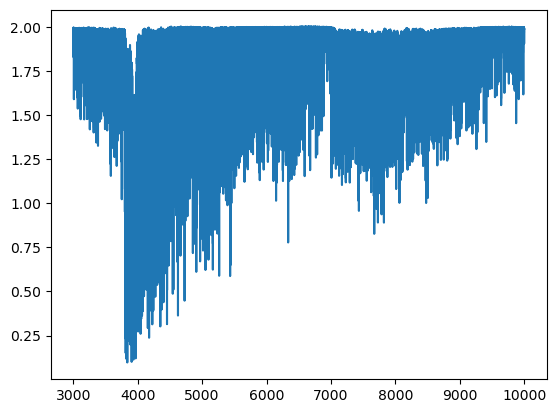

In [24]:
plt.plot(vws, spectra_body1[0, :, 0]/spectra_body1[0, :, 1]+spectra_body2[0, :, 0]/spectra_body2[0, :, 1])
plt.show()

## Save the spectra and meshes

In [ ]:
os.makedirs(output_dir, exist_ok=True)

with open(f'{output_dir}/tz_fornacis_data_{num_wavelengths}.pkl', 'wb') as f:
    pickle.dump({
        'spectra_body1': spectra_body1,
        'spectra_body2': spectra_body2,
        'mesh_body1': pb1,
        'mesh_body2': pb2,
        'wavelengths': vws,
        'times': times
    }, f)

print(f"\u2713 Spectra data saved to {output_dir}/tz_fornacis_data_{num_wavelengths}.pkl")